# 데이터 비식별화
: 이름, 주소, 주민등록번호 등과 같은 개인 식별 가능 정보를 삭제하거나 가명 처리, 범주화, 마스킹 등 다양한 방법으로 대체해 특정 개인을 식별할 수 없도록 만드는 작업

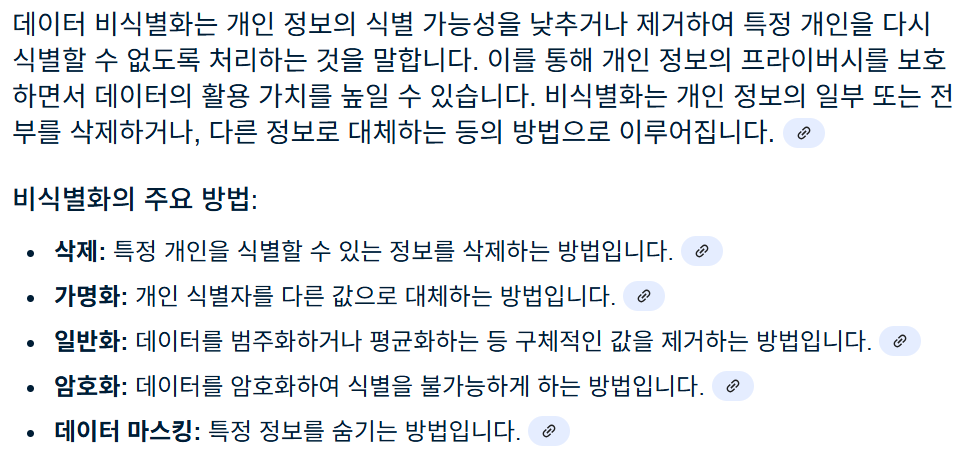

***

## 1. 마스킹(Masking)
데이터의 일부를 가려서 개인 식별 정보를 숨긴다.
- 예시: 이름의 일부를 *로 대체

In [1]:
import pandas as pd

df = pd.DataFrame({'Name': ['홍길동', '김철수', '이영희']})
df['Masked_Name'] = df['Name'].str[0] + '**'
print(df)

  Name Masked_Name
0  홍길동         홍**
1  김철수         김**
2  이영희         이**


## 2. 가명 처리(Pseudonymization)
실제 정보를 가짜 정보로 대체한다.
- 대표 라이브러리: Faker

In [2]:
from faker import Faker
import pandas as pd

fake = Faker('ko_KR')
df = pd.DataFrame({'Name': ['홍길동', '김철수', '이영희']})
df['Pseudonym'] = [fake.name() for _ in range(len(df))]
print(df)

  Name Pseudonym
0  홍길동       한민준
1  김철수       주현숙
2  이영희       이서윤


## 3. 범주화(Binning)
민감한 값을 범위로 묶어 비식별화한다. (예: 나이, 연봉 등)

- Pandas의 Cut 함수는 연속적인 수치 데이터를 범주형 데이터로 변환

> bins
> - 예를 들어, [0, 4, 8, 12, 24]는 0~4, 4~8, 8~12, 12~24의 네 구간으로 데이터를 나누겠다는 의미
> - 구간의 경계는 왼쪽은 포함하지 않고(단, 첫 구간의 시작점은 포함), 오른쪽은 포함하는 방식으로 정의
> - bins에 의해 정의된 구간 수와 labels 리스트의 요소의 개수는 일치해야 한다!

In [3]:
import pandas as pd

df = pd.DataFrame({'Age': [17, 25, 38, 52, 67]})
bins = [0, 18, 30, 45, 60, 100] # bins 파라미터는 데이터를 나눌 구간의 경계
labels = ['0-18', '19-30', '31-45', '46-60', '60+'] # 각 구간에 할당할 레이블을 정의
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
print(df)

   Age Age_Group
0   17      0-18
1   25     19-30
2   38     31-45
3   52     46-60
4   67       60+


## 4. 데이터 마스킹 및 가명화 자동화 라이브러리 활용
anonymizedf, DIL-Project, Faker 등 다양한 라이브러리로 자동화 가능
- Faker: 다양한 가짜 데이터 생성
- anonymizedf: 데이터프레임 단위 자동 가명화
- DIL-Project: 국내 개발, 다양한 가명처리 기법 지원

In [4]:
from anonymizedf.anonymizedf import anonymize
import pandas as pd

df = pd.DataFrame({
    'Name': ['홍길동', '김철수', '이영희'],
    'Salary': [5000, 6000, 7000],
    'Age': [25, 35, 45],
    'City': ['서울', '부산', '대구']
})

an = anonymize(df)
fake_df = (
    an
    .fake_names("Name", chaining=True)
    .fake_whole_numbers("Salary", chaining=True)
    .fake_whole_numbers("Age", chaining=True)
    .fake_categories("City", chaining=True)
    .show_data_frame()
)
print(fake_df)

  Name  Salary  Age City    Fake_Name  Fake_Salary  Fake_Age Fake_City
0  홍길동    5000   25   서울  Carl Carter         6188        38    City 1
1  김철수    6000   35   부산    Sam Lewis         5085        25    City 2
2  이영희    7000   45   대구  Jeremy Shah         5338        37    City 3


***

## 영문 이름, 카드 정보 비식별화

카드정보(신용카드 번호) 비식별화
- 정규표현식(Regex) 활용
- 카드번호는 일정한 패턴(예: 16자리 숫자)으로 구성되어 있어 정규표현식으로 쉽게 탐지 및 마스킹할 수 있다.

In [5]:
import re

text = "John's card number is 1234-5678-9012-3456."
masked = re.sub(r'\b(?:\d[ -]*?){13,16}\b', '****-****-****-****', text)
print(masked)

John's card number is ****-****-****-****.


영문 이름 비식별화

In [7]:
import re

def deidentify_english_names(text):
    # 대문자로 시작하고 소문자가 이어지는 이름 + 공백 + 대문자로 시작하고 소문자가 이어지는 성
    pattern = r'\b[A-Z][a-z]+ [A-Z][a-z]+\b'
    
    # 이름을 *** ***로 대체
    masked_text = re.sub(pattern, '*** ***', text)
    
    return masked_text

# 예시
text = "John Smith paid with his card. Alice Johnson sent an email."
masked = deidentify_english_names(text)
print(masked)

*** *** paid with his card. *** *** sent an email.
